In [1]:
 !pip install datasets

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

Total rows (all data roles): 785,741
Data Analyst rows: 196,075


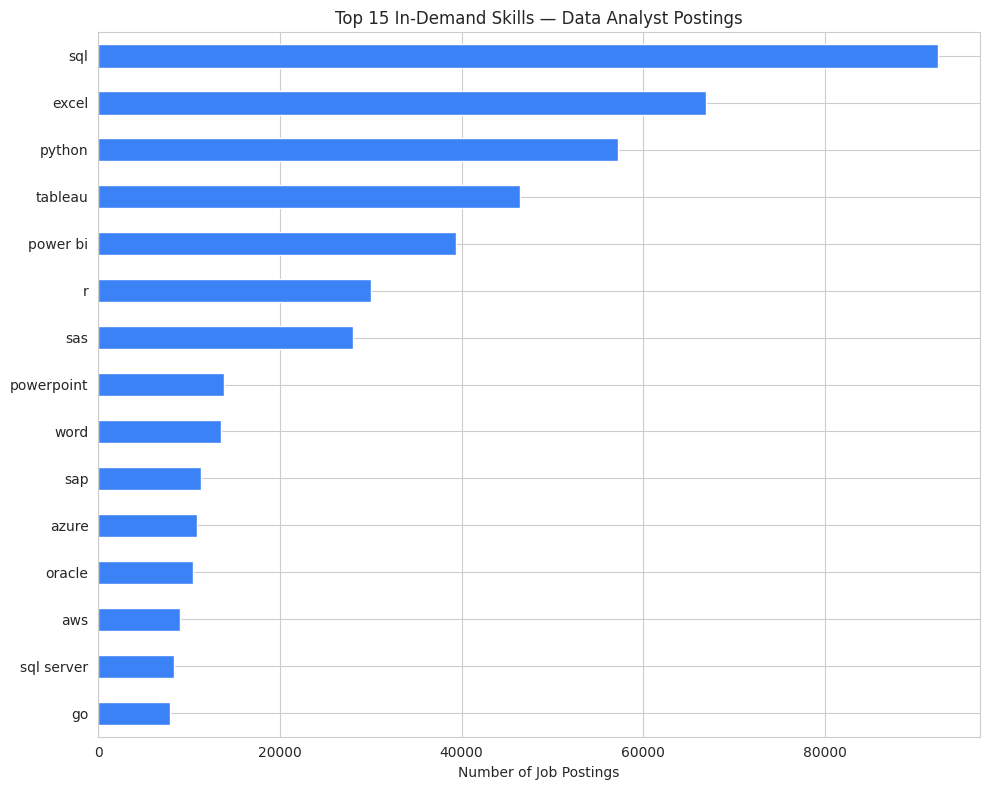

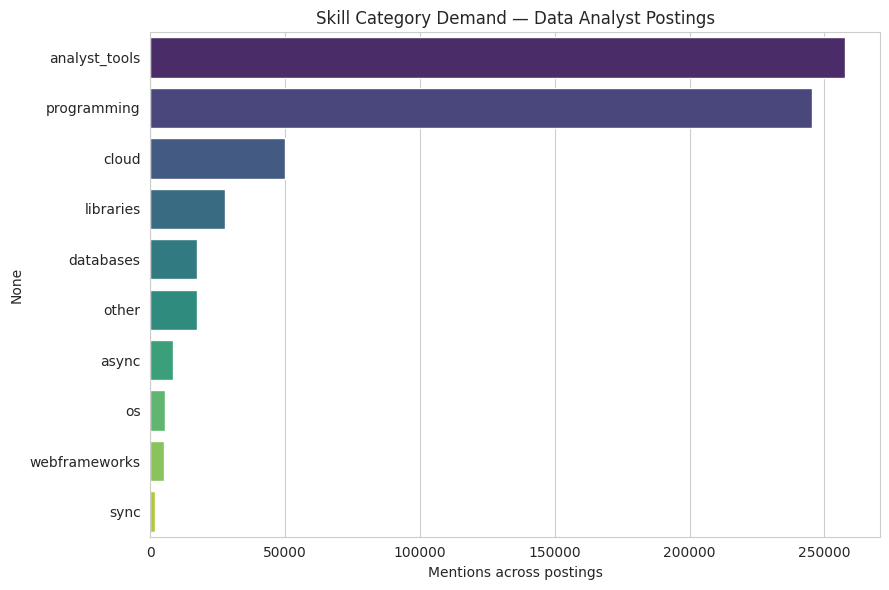

Postings with salary data: 5,451 (2.8% of Data Analyst postings)


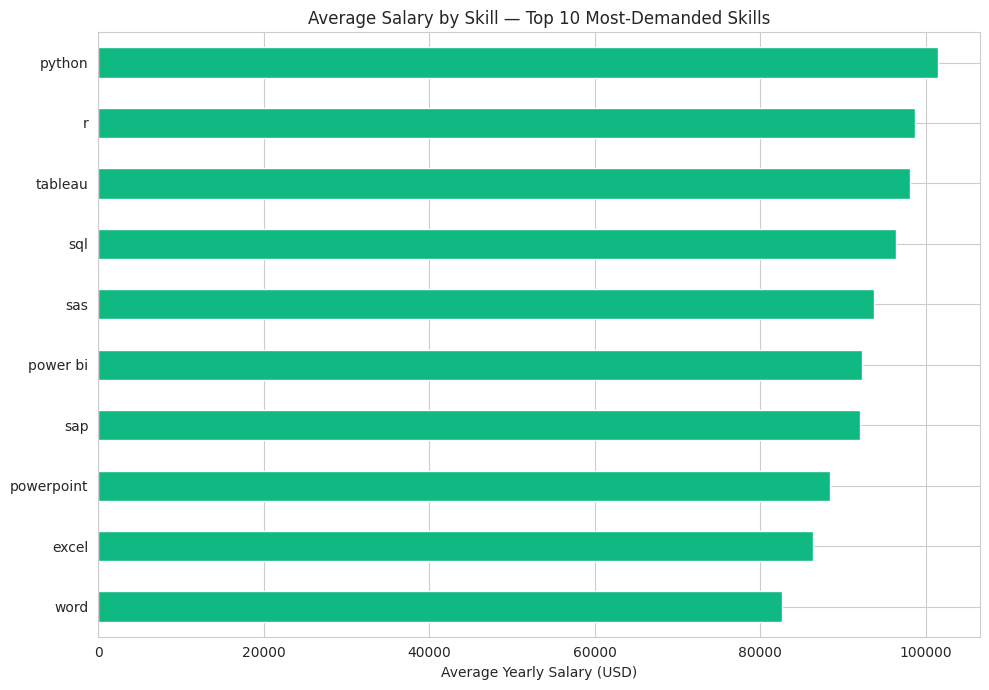

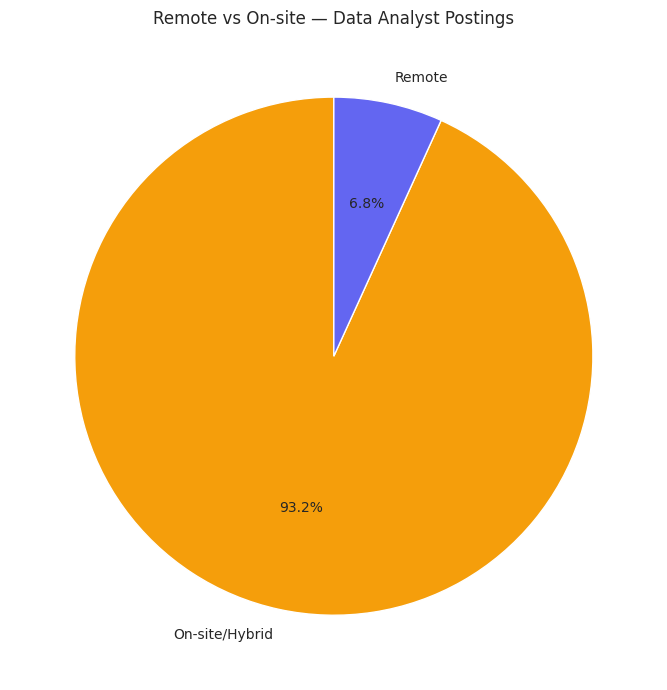

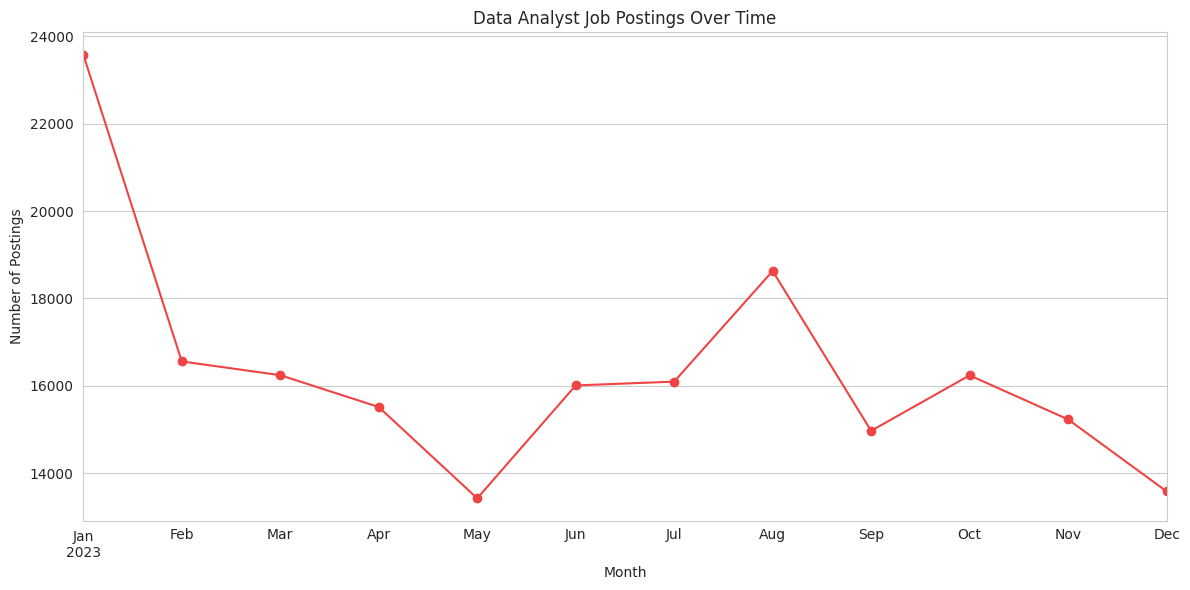

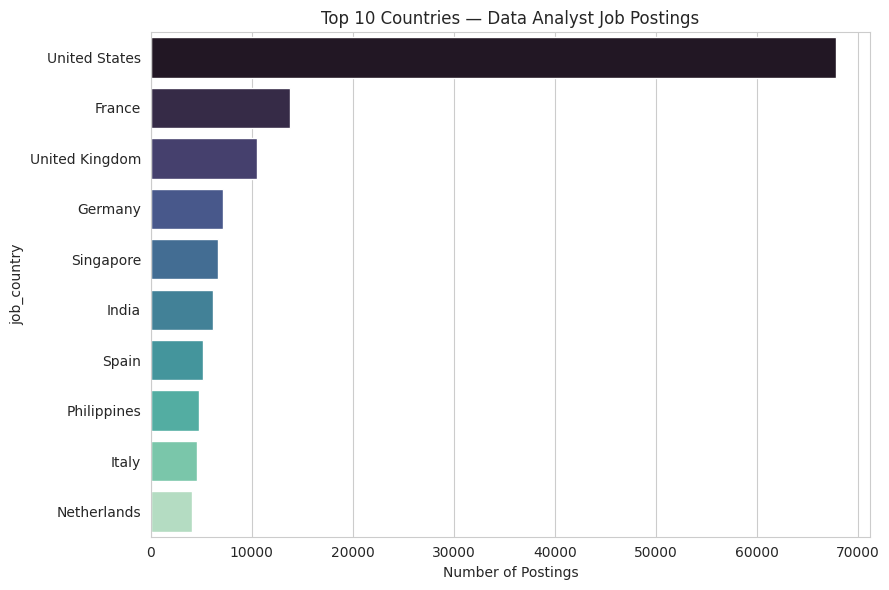


=== KEY FINDINGS (draft for README) ===
- Analyzed 196,075 Data Analyst job postings globally.
- Most in-demand skill: sql (92,428 postings).
- Most in-demand skill category: analyst_tools.
- Highest-paying skill (among top 10 most-demanded): python ($101,457/yr avg).
- Lowest-paying among top 10 most-demanded: word ($82,617/yr avg).
- 6.8% of postings are remote.
- Top hiring country: United States (67,816 postings).

All charts + cleaned CSV saved in 'outputs/'.


In [2]:
"""
Data Analyst Job Market Analysis
===================================
Project #5 in Sahil Kumar's data analytics portfolio.

Data source: lukebarousse/data_jobs (HuggingFace) — same dataset as Kaggle's
"Data Analyst Job Postings [Pay, Skills, Benefits]", 786k+ global job postings
scraped from Google Search, updated regularly. We filter to "Data Analyst" role.

Run this in Google Colab.
"""

# %% 1. Install & load data --------------------------------------------------
# !pip install datasets   # uncomment/run in Colab

import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_style("whitegrid")
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("Downloading dataset (this can take a few minutes, ~290MB)...")
ds = load_dataset("lukebarousse/data_jobs")
df_all = ds["train"].to_pandas()
print(f"Total rows (all data roles): {len(df_all):,}")

# Filter to Data Analyst roles only
df = df_all[df_all["job_title_short"] == "Data Analyst"].copy()
print(f"Data Analyst rows: {len(df):,}")

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], errors="coerce")

# %% 2. Parse skills (stored as string-representation of a Python list) ------
def parse_skill_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x) if isinstance(x, str) else list(x)
    except (ValueError, SyntaxError):
        return []

df["skills_list"] = df["job_skills"].apply(parse_skill_list)

# %% 3. Chart 1 — Top 15 in-demand skills -------------------------------------
all_skills = [s for skills in df["skills_list"] for s in skills]
skill_counts = Counter(all_skills)
top_skills = pd.Series(dict(skill_counts.most_common(15))).sort_values()

plt.figure(figsize=(10, 8))
top_skills.plot(kind="barh", color="#3b82f6")
plt.title("Top 15 In-Demand Skills — Data Analyst Postings")
plt.xlabel("Number of Job Postings")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/1_top_skills.png", dpi=150)
plt.show()

# %% 4. Chart 2 — Skill category breakdown (from job_type_skills) ------------
def parse_skill_dict(x):
    if pd.isna(x):
        return {}
    try:
        return ast.literal_eval(x) if isinstance(x, str) else dict(x)
    except (ValueError, SyntaxError):
        return {}

df["skills_dict"] = df["job_type_skills"].apply(parse_skill_dict)

category_counts = Counter()
for d in df["skills_dict"]:
    for category, skills in d.items():
        category_counts[category] += len(skills)

cat_series = pd.Series(dict(category_counts)).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=cat_series.values, y=cat_series.index, hue=cat_series.index,
            palette="viridis", legend=False)
plt.title("Skill Category Demand — Data Analyst Postings")
plt.xlabel("Mentions across postings")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/2_skill_categories.png", dpi=150)
plt.show()

# %% 5. Chart 3 — Salary by top skill -----------------------------------------
salary_df = df.dropna(subset=["salary_year_avg"])
print(f"Postings with salary data: {len(salary_df):,} "
      f"({100*len(salary_df)/len(df):.1f}% of Data Analyst postings)")

top_10_skills = [s for s, _ in skill_counts.most_common(10)]
skill_salary = {}
for skill in top_10_skills:
    mask = salary_df["skills_list"].apply(lambda lst: skill in lst)
    if mask.sum() > 0:
        skill_salary[skill] = salary_df.loc[mask, "salary_year_avg"].mean()

skill_salary_series = pd.Series(skill_salary).sort_values()

plt.figure(figsize=(10, 7))
skill_salary_series.plot(kind="barh", color="#10b981")
plt.title("Average Salary by Skill — Top 10 Most-Demanded Skills")
plt.xlabel("Average Yearly Salary (USD)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/3_salary_by_skill.png", dpi=150)
plt.show()

# %% 6. Chart 4 — Remote vs onsite ---------------------------------------------
remote_counts = df["job_work_from_home"].value_counts()
remote_counts.index = remote_counts.index.map({True: "Remote", False: "On-site/Hybrid"})

plt.figure(figsize=(7, 7))
plt.pie(remote_counts.values, labels=remote_counts.index, autopct="%1.1f%%",
        colors=["#f59e0b", "#6366f1"], startangle=90)
plt.title("Remote vs On-site — Data Analyst Postings")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/4_remote_vs_onsite.png", dpi=150)
plt.show()

# %% 7. Chart 5 — Postings over time -------------------------------------------
monthly_postings = df.dropna(subset=["job_posted_date"]).groupby(
    df["job_posted_date"].dt.to_period("M")
).size()
monthly_postings.index = monthly_postings.index.to_timestamp()

plt.figure(figsize=(12, 6))
monthly_postings.plot(marker="o", color="#ef4444")
plt.title("Data Analyst Job Postings Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/5_postings_over_time.png", dpi=150)
plt.show()

# %% 8. Bonus — Top countries --------------------------------------------------
top_countries = df["job_country"].value_counts().head(10)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="mako", legend=False)
plt.title("Top 10 Countries — Data Analyst Job Postings")
plt.xlabel("Number of Postings")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/6_top_countries.png", dpi=150)
plt.show()

# %% 9. Findings summary (for the README) --------------------------------------
top_skill = top_skills.index[-1]
top_skill_count = top_skills.iloc[-1]
top_category = cat_series.index[0]
highest_paid_skill = skill_salary_series.idxmax()
lowest_paid_skill = skill_salary_series.idxmin()
remote_pct = remote_counts.get("Remote", 0) / remote_counts.sum() * 100
top_country = top_countries.index[0]

print("\n=== KEY FINDINGS (draft for README) ===")
print(f"- Analyzed {len(df):,} Data Analyst job postings globally.")
print(f"- Most in-demand skill: {top_skill} ({top_skill_count:,} postings).")
print(f"- Most in-demand skill category: {top_category}.")
print(f"- Highest-paying skill (among top 10 most-demanded): {highest_paid_skill} "
      f"(${skill_salary_series.max():,.0f}/yr avg).")
print(f"- Lowest-paying among top 10 most-demanded: {lowest_paid_skill} "
      f"(${skill_salary_series.min():,.0f}/yr avg).")
print(f"- {remote_pct:.1f}% of postings are remote.")
print(f"- Top hiring country: {top_country} ({top_countries.iloc[0]:,} postings).")

df.drop(columns=["skills_list", "skills_dict"]).to_csv(
    f"{OUT_DIR}/data_analyst_jobs_clean.csv", index=False
)
print(f"\nAll charts + cleaned CSV saved in '{OUT_DIR}/'.")

In [3]:
 !zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/data_analyst_jobs_clean.csv (deflated 80%)
  adding: outputs/1_top_skills.png (deflated 30%)
  adding: outputs/6_top_countries.png (deflated 24%)
  adding: outputs/2_skill_categories.png (deflated 25%)
  adding: outputs/4_remote_vs_onsite.png (deflated 12%)
  adding: outputs/3_salary_by_skill.png (deflated 27%)
  adding: outputs/5_postings_over_time.png (deflated 14%)
